# Сравнение моделей U-net и res-U-net

Код делает сравнение двух нейросетей (UNet и ResUNet) на тестовых изображениях. Каждая модель предсказывает маску линий сетки, затем эта маска обрабатывается математическими алгоритмами, чтобы получить координаты линий, разбить на ячейки и определить цвета.

In [28]:
import cv2
import torch
import numpy as np
# import pandas as pd
import json
import torchvision.transforms as transforms
# from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from pathlib import Path
import os
from architectures import create_model

In [29]:
def compute_metrics(pred_mask, true_mask):
    """
    Вычисляет метрики сегментации без использования sklearn/pandas
    
    Args:
        pred_mask: предсказанная бинарная маска (0 или 255)
        true_mask: истинная бинарная маска (0 или 255)
    
    Returns:
        dict: {'iou', 'dice', 'precision', 'recall'}
    """
    # Приводим к бинарным (0/1)
    pred = (pred_mask > 127).astype(np.uint8)
    true = (true_mask > 127).astype(np.uint8)
    
    # Подсчёт пикселей
    tp = np.sum((pred == 1) & (true == 1))
    fp = np.sum((pred == 1) & (true == 0))
    fn = np.sum((pred == 0) & (true == 1))
    
    # Метрики
    iou = tp / (tp + fp + fn + 1e-9)
    dice = 2 * tp / (2 * tp + fp + fn + 1e-9)
    precision = tp / (tp + fp + 1e-9)
    recall = tp / (tp + fn + 1e-9)
    
    return {
        'iou': iou,
        'dice': dice,
        'precision': precision,
        'recall': recall
    }


def print_metrics_table(results):
    """
    Выводит таблицу метрик в консоль
    """
    print("\n" + "="*80)
    print("📊 СРАВНЕНИЕ МЕТРИК")
    print("="*80)
    print(f"{'Изображение':<35} {'IoU':<8} {'Dice':<8} {'Precision':<10} {'Recall':<8}")
    print("-"*80)
    
    total_iou = {'unet': 0, 'resunet': 0}
    total_dice = {'unet': 0, 'resunet': 0}
    count = 0
    
    for r in results:
        if r['unet_metrics'] and r['resunet_metrics']:
            print(f"{r['image'][:33]:<35} "
                  f"{r['unet_metrics']['iou']:.3f}    "
                  f"{r['unet_metrics']['dice']:.3f}    "
                  f"{r['unet_metrics']['precision']:.3f}      "
                  f"{r['unet_metrics']['recall']:.3f}")
            print(f"{'':35} "
                  f"{r['resunet_metrics']['iou']:.3f}    "
                  f"{r['resunet_metrics']['dice']:.3f}    "
                  f"{r['resunet_metrics']['precision']:.3f}      "
                  f"{r['resunet_metrics']['recall']:.3f}  ← ResUNet")
            print("-"*80)
            
            total_iou['unet'] += r['unet_metrics']['iou']
            total_iou['resunet'] += r['resunet_metrics']['iou']
            total_dice['unet'] += r['unet_metrics']['dice']
            total_dice['resunet'] += r['resunet_metrics']['dice']
            count += 1
    
    if count > 0:
        print("\n📈 СРЕДНИЕ ЗНАЧЕНИЯ:")
        print(f"   U-Net:    IoU={total_iou['unet']/count:.4f}, Dice={total_dice['unet']/count:.4f}")
        print(f"   ResUNet:  IoU={total_iou['resunet']/count:.4f}, Dice={total_dice['resunet']/count:.4f}")

In [ ]:
"""
Сравнение UNet и ResUNet на тестовых изображениях
"""

######################
# ГЛОБАЛЬНЫЕ НАСТРОЙКИ

PARAMS = {
    'hough_threshold': 50,
    'hough_min_length_ratio': 4,     # minLineLength = min(h,w) // ratio
    'hough_max_gap': 20,
    'angle_horiz': 20,
    'angle_vert_low': 70,
    'angle_vert_high': 110,
    'length_ratio': 0.30,
    'group_threshold': 15,
    'max_gap_ratio': 1.5,
    'binary_threshold': 0.5,
    'image_size': 512,
    'tolerance_ratio': 0.3,          # для выравнивания ячеек
}

# Восстанавливает пропущенные линии внутри существующей сетки
# Если между двумя линиями разрыв больше [median_gap * max_gap_ratio], добавляет недостающие линии
def fix_missing_lines(h_lines, v_lines, img_shape, max_gap_ratio=1.5):
    """
    Восстанавливает пропущенные линии ТОЛЬКО между существующими границами
    """
    h, w = img_shape[:2]

    # Восстанавливаем горизонтальные линии (между первой и последней)
    if len(h_lines) >= 2:
        gaps = np.diff(h_lines)
        median_gap = int(np.median(gaps))

        fixed_h = [h_lines[0]]  # начинаем с первой линии
        for i in range(1, len(h_lines)):
            gap = h_lines[i] - fixed_h[-1]
            if gap > median_gap * max_gap_ratio:
                # Добавляем пропущенные линии между существующими
                num_missing = int(round(gap / median_gap)) - 1
                for j in range(1, num_missing + 1):
                    new_y = fixed_h[-1] + j * median_gap
                    # за пределы последней линии ничего не добавляем
                    if new_y < h_lines[-1]:
                        fixed_h.append(new_y)
            fixed_h.append(h_lines[i])
        h_lines = fixed_h

    # Восстанавливаем вертикальные линии (только между первой и последней)
    if len(v_lines) >= 2:
        gaps = np.diff(v_lines)
        median_gap = int(np.median(gaps))

        fixed_v = [v_lines[0]]  # начинаем с первой линии
        for i in range(1, len(v_lines)):
            gap = v_lines[i] - fixed_v[-1]
            if gap > median_gap * max_gap_ratio:
                num_missing = int(round(gap / median_gap)) - 1
                for j in range(1, num_missing + 1):
                    new_x = fixed_v[-1] + j * median_gap
                    # за пределы последней линии ничего не добавляем
                    if new_x < v_lines[-1]:
                        fixed_v.append(new_x)
            fixed_v.append(v_lines[i])
        v_lines = fixed_v

    return sorted(set(h_lines)), sorted(set(v_lines))

# Выравнивает расстояния между линиями, чтобы ячейки были примерно одного размера
# Может выбрать проблемы на фото изображений, когда наблюдается перекос, но сильно помогает на сканах
def equalize_cell_sizes(h_lines, v_lines, img_shape, max_gap_ratio=1.8):
    """
    Добавляет пропущенные линии между существующими, если расстояния слишком большие.
    Существующие линии НЕ ПЕРЕДВИГАЮТСЯ.

    max_gap_ratio: если расстояние между линиями больше median_gap * max_gap_ratio,
                   добавляем промежуточные линии.
    """
    h, w = img_shape[:2]

    # === Горизонтальные линии ===
    if len(h_lines) >= 2:
        # Вычисляем медианный шаг
        gaps = np.diff(h_lines)
        median_gap = int(np.median(gaps))

        fixed_h = [h_lines[0]]

        for i in range(1, len(h_lines)):
            gap = h_lines[i] - fixed_h[-1]

            # Если разрыв слишком большой, добавляем линии
            if gap > median_gap * max_gap_ratio:
                # Сколько линий нужно добавить
                num_missing = int(round(gap / median_gap)) - 1
                # Ограничиваем, чтобы не переборщить
                num_missing = min(num_missing, 10)

                step = gap / (num_missing + 1)

                for j in range(1, num_missing + 1):
                    new_y = int(fixed_h[-1] + j * step)
                    fixed_h.append(new_y)

            fixed_h.append(h_lines[i])

        h_lines = fixed_h

    # === Вертикальные линии ===
    if len(v_lines) >= 2:
        gaps = np.diff(v_lines)
        median_gap = int(np.median(gaps))

        fixed_v = [v_lines[0]]

        for i in range(1, len(v_lines)):
            gap = v_lines[i] - fixed_v[-1]

            if gap > median_gap * max_gap_ratio:
                num_missing = int(round(gap / median_gap)) - 1
                num_missing = min(num_missing, 10)

                step = gap / (num_missing + 1)

                for j in range(1, num_missing + 1):
                    new_x = int(fixed_v[-1] + j * step)
                    fixed_v.append(new_x)

            fixed_v.append(v_lines[i])

        v_lines = fixed_v

    return h_lines, v_lines

# Группирует близко расположенные линии в одну
# Из-за шумов часто линии "наезжают" друг на друга
def group_lines(lines, threshold=15):
    """Группировка близких линий"""
    if not lines:
        return []
    lines = sorted(lines)
    grouped = []
    current = [lines[0]]
    for line in lines[1:]:
        if line - current[-1] < threshold:
            current.append(line)
        else:
            grouped.append(int(np.median(current)))
            current = [line]
    grouped.append(int(np.median(current)))
    return grouped


# Черновой вариант обработки цвета ячеек
def get_cell_color(cell_img):
    """Определяет доминирующий цвет в ячейке (без sklearn)"""
    h, w = cell_img.shape[:2]
    if h > 10 and w > 10:
        inner = cell_img[5:h-5, 5:w-5]
    else:
        inner = cell_img
    
    pixels = inner.reshape(-1, 3)
    if len(pixels) < 5:
        return [128, 128, 128]
    
    # Простое среднее арифметическое вместо KMeans
    color = np.mean(pixels, axis=0).astype(int)
    
    return color.tolist()

# Превращает бинарную маску (белые линии, чёрный фон) в готовую сетку и RGB-матрицу
def process_mask(binary_mask, original_image, params=PARAMS):
    """
    Единая постобработка для любой маски
    Возвращает: h_lines, v_lines, rgb_matrix, rows, cols
    """
    original_h, original_w = original_image.shape[:2]

    ##############################################
    # HoughLinesP находит все прямые линии в маске
    min_line_length = min(original_h, original_w) // params['hough_min_length_ratio']

    lines = cv2.HoughLinesP(
        binary_mask,
        rho=1,
        theta=np.pi/180,
        threshold=params['hough_threshold'],
        minLineLength=min_line_length,
        maxLineGap=params['hough_max_gap']
    )

    if lines is None:
        return None, None, None, 0, 0

    ##############################################
    # Сбор горизонтальных и вертикальных линий
    # отделяет горизонтальные от вертикальных, фильтрует по углу и длине
    horizontal_lines = []
    vertical_lines = []

    for line in lines:
        x1, y1, x2, y2 = line[0]
        angle = abs(np.arctan2(y2 - y1, x2 - x1) * 180 / np.pi)
        length = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)

        # Горизонтальные линии
        if angle < params['angle_horiz'] or angle > (180 - params['angle_horiz']):
            if length > original_w * params['length_ratio']:
                horizontal_lines.append((y1 + y2) // 2)
        # Вертикальные линии
        elif params['angle_vert_low'] < angle < params['angle_vert_high']:
            if length > original_h * params['length_ratio']:
                vertical_lines.append((x1 + x2) // 2)

    # Группировка - объединение близких линий
    h_lines = group_lines(horizontal_lines, threshold=params['group_threshold'])
    v_lines = group_lines(vertical_lines, threshold=params['group_threshold'])

    # Восстановление пропущенных линий
    h_lines, v_lines = fix_missing_lines(h_lines, v_lines, (original_h, original_w),
                                          max_gap_ratio=params['max_gap_ratio'])

    # Выравнивание ячеек - лучше отключить, если сетка сильно поехала.
    # h_lines, v_lines = equalize_cell_sizes(h_lines, v_lines, (original_h, original_w),
    #                                         tolerance_ratio=params['tolerance_ratio'])

    h_lines, v_lines = equalize_cell_sizes(h_lines, v_lines, (original_h, original_w),
                                        max_gap_ratio=1.8)

    # Если сетка не получилась (меньше 2 горизонтальных или меньше 2 вертикальных линий),
    # функция возвращает None и нули
    rows = len(h_lines) - 1
    cols = len(v_lines) - 1

    if rows <= 0 or cols <= 0:
        return None, None, None, 0, 0

    # 6. Сбор цветов
    rgb_matrix = []
    for i in range(rows):
        row_colors = []
        y1 = max(0, h_lines[i])
        y2 = min(original_h, h_lines[i + 1])
        for j in range(cols):
            x1 = max(0, v_lines[j])
            x2 = min(original_w, v_lines[j + 1])
            cell = original_image[y1:y2, x1:x2]
            row_colors.append(get_cell_color(cell))
        rgb_matrix.append(row_colors)

    return h_lines, v_lines, rgb_matrix, rows, cols


#################################################################

# Загружает картинку, прогоняет через нейросеть, получает маску и применяет постобработку
def predict_mask(model, image_path, device='cuda', params=PARAMS):
    """
    Предсказание маски для одной модели + постобработка
    """
    model.eval()

    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    original_h, original_w = img_rgb.shape[:2]

    # Предсказание
    transform = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((params['image_size'], params['image_size'])),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                           std=[0.229, 0.224, 0.225])
    ])

    input_tensor = transform(img_rgb).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_tensor)
        mask = torch.sigmoid(output).cpu().squeeze().numpy()
        mask = cv2.resize(mask, (original_w, original_h))
        binary_mask = (mask > params['binary_threshold']).astype(np.uint8) * 255

    # Постобработка
    h_lines, v_lines, rgb_matrix, rows, cols = process_mask(binary_mask, img_rgb, params)

    return h_lines, v_lines, rgb_matrix, rows, cols, img_rgb, binary_mask


############################################################################

# Итоговая визуализация и сравнение
def visualize_comparison(image_path, unet_result, resunet_result, output_dir):
    """Визуализация сравнения UNet vs ResUNet"""

    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    filename = Path(image_path).stem

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))

    # Ряд 1: UNet
    unet_has_grid = unet_result[0] is not None
    unet_img = unet_result[5] if unet_result[5] is not None else img_rgb
    unet_mask = unet_result[6] if unet_result[6] is not None else np.zeros_like(img_rgb[:,:,0])

    img_grid = unet_img.copy()
    if unet_has_grid:
        h, v = unet_result[0], unet_result[1]
        rows, cols = unet_result[3], unet_result[4]
        for y in h: cv2.line(img_grid, (0, y), (img_rgb.shape[1], y), (255, 0, 0), 2)
        for x in v: cv2.line(img_grid, (x, 0), (x, img_rgb.shape[0]), (255, 0, 0), 2)
        axes[0, 0].set_title(f'UNet: сетка\n{rows}x{cols}')
    else:
        axes[0, 0].set_title('UNet: сетка НЕ найдена')
    axes[0, 0].imshow(img_grid)
    axes[0, 0].axis('off')

    axes[0, 1].imshow(unet_mask, cmap='gray')
    axes[0, 1].set_title('UNet: маска')
    axes[0, 1].axis('off')

    if unet_has_grid:
        h, v, rgb, rows, cols = unet_result[:5]
        h_viz, w_viz = img_rgb.shape[:2]
        rgb_viz = np.zeros((h_viz, w_viz, 3), dtype=np.uint8)
        for i in range(rows):
            y1, y2 = h[i], h[i+1]
            for j in range(cols):
                x1, x2 = v[j], v[j+1]
                rgb_viz[y1:y2, x1:x2] = rgb[i][j]
        axes[0, 2].imshow(rgb_viz)
        axes[0, 2].set_title('UNet: RGB-матрица')
    else:
        axes[0, 2].text(0.5, 0.5, 'Нет данных', ha='center', va='center')
    axes[0, 2].axis('off')

    # Ряд 2: ResUNet
    resunet_has_grid = resunet_result[0] is not None
    resunet_img = resunet_result[5] if resunet_result[5] is not None else img_rgb
    resunet_mask = resunet_result[6] if resunet_result[6] is not None else np.zeros_like(img_rgb[:,:,0])

    img_grid = resunet_img.copy()
    if resunet_has_grid:
        h, v = resunet_result[0], resunet_result[1]
        rows, cols = resunet_result[3], resunet_result[4]
        for y in h: cv2.line(img_grid, (0, y), (img_rgb.shape[1], y), (255, 0, 0), 2)
        for x in v: cv2.line(img_grid, (x, 0), (x, img_rgb.shape[0]), (255, 0, 0), 2)
        axes[1, 0].set_title(f'ResUNet: сетка\n{rows}x{cols}')
    else:
        axes[1, 0].set_title('ResUNet: сетка НЕ найдена')
    axes[1, 0].imshow(img_grid)
    axes[1, 0].axis('off')

    axes[1, 1].imshow(resunet_mask, cmap='gray')
    axes[1, 1].set_title('ResUNet: маска')
    axes[1, 1].axis('off')

    if resunet_has_grid:
        h, v, rgb, rows, cols = resunet_result[:5]
        h_viz, w_viz = img_rgb.shape[:2]
        rgb_viz = np.zeros((h_viz, w_viz, 3), dtype=np.uint8)
        for i in range(rows):
            y1, y2 = h[i], h[i+1]
            for j in range(cols):
                x1, x2 = v[j], v[j+1]
                rgb_viz[y1:y2, x1:x2] = rgb[i][j]
        axes[1, 2].imshow(rgb_viz)
        axes[1, 2].set_title('ResUNet: RGB-матрица')
    else:
        axes[1, 2].text(0.5, 0.5, 'Нет данных', ha='center', va='center')
    axes[1, 2].axis('off')

    plt.tight_layout()
    save_path = os.path.join(output_dir, f'comparison_{filename}.png')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"💾 Сохранено: {save_path}")


def compare_models(
    unet_weights_path,
    resunet_weights_path,
    test_images_dir='test_images',
    output_dir='comparison_results',
    device='cuda',
    params=PARAMS
):
    """
    Сравнение UNet и ResUNet на тестовых изображениях
    """
    print("="*60)
    print("🔬 СРАВНЕНИЕ UNet vs ResUNet")
    print("="*60)

    os.makedirs(output_dir, exist_ok=True)
    device = torch.device(device if torch.cuda.is_available() else 'cpu')
    print(f"🚀 Устройство: {device}")

    # Загрузка моделей
    print("\n📦 Загрузка моделей...")
    unet = create_model('unet', n_channels=3, n_classes=1).to(device)
    resunet = create_model('resunet', n_channels=3, n_classes=1).to(device)

    unet.load_state_dict(torch.load(unet_weights_path, map_location=device))
    resunet.load_state_dict(torch.load(resunet_weights_path, map_location=device))
    print("✅ Модели загружены")

    # Поиск тестовых изображений
    extensions = ('.jpg', '.jpeg', '.png')
    test_images = [f for f in os.listdir(test_images_dir) if f.lower().endswith(extensions)]

    if not test_images:
        print(f"❌ Нет изображений в папке {test_images_dir}")
        return

    print(f"\n📂 Найдено тестовых изображений: {len(test_images)}")

    all_results = []

    for idx, img_name in enumerate(test_images):
        print(f"\n{'='*50}")
        print(f"[{idx+1}/{len(test_images)}] Обработка: {img_name}")
        print(f"{'='*50}")

        img_path = os.path.join(test_images_dir, img_name)
        name_no_ext = Path(img_name).stem

        # UNet
        print("🟢 UNet...")
        unet_result = predict_mask(unet, img_path, device, params)
        unet_ok = unet_result[0] is not None
        if unet_ok:
            print(f"   ✅ Сетка: {unet_result[3]}x{unet_result[4]}")
        else:
            print("   ❌ Не удалось определить сетку")

        # ResUNet
        print("🟢 ResUNet...")
        resunet_result = predict_mask(resunet, img_path, device, params)
        resunet_ok = resunet_result[0] is not None
        if resunet_ok:
            print(f"   ✅ Сетка: {resunet_result[3]}x{resunet_result[4]}")
        else:
            print("   ❌ Не удалось определить сетку")


        # вычисление метрик
        unet_metrics = None
        resunet_metrics = None
        
        # Ищем истинную маску
        mask_path = os.path.join('val_masks', f"{Path(img_path).stem}_mask.png")
        
        if os.path.exists(mask_path):
            true_mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            
            if true_mask is not None:
                # Приводим истинную маску к размеру предсказанной
                if true_mask.shape != unet_result[6].shape:
                    true_mask = cv2.resize(true_mask, (unet_result[6].shape[1], unet_result[6].shape[0]))
                
                # UNet метрики
                if unet_result[6] is not None:
                    iou, dice, prec, rec = compute_metrics(unet_result[6], true_mask)
                    unet_metrics = {'iou': iou, 'dice': dice, 'precision': prec, 'recall': rec}
                    print(f"   📊 UNet: IoU={iou:.3f}, Dice={dice:.3f}, Prec={prec:.3f}, Rec={rec:.3f}")
                
                # ResUNet метрики
                if resunet_result[6] is not None:
                    iou, dice, prec, rec = compute_metrics(resunet_result[6], true_mask)
                    resunet_metrics = {'iou': iou, 'dice': dice, 'precision': prec, 'recall': rec}
                    print(f"   📊 ResUNet: IoU={iou:.3f}, Dice={dice:.3f}, Prec={prec:.3f}, Rec={rec:.3f}")
            else:
                print("   ⚠️ Не удалось загрузить истинную маску")
        else:
            print(f"   ⚠️ Истинная маска не найдена: {mask_path}")
        # ================================

        # Визуализация сравнения
        visualize_comparison(img_path, unet_result, resunet_result, output_dir)

        # Сохраняем результаты
        all_results.append({
            'image': img_name,
            'unet_success': unet_ok,
            'unet_size': f"{unet_result[3]}x{unet_result[4]}" if unet_ok else '-',
            'resunet_success': resunet_ok,
            'resunet_size': f"{resunet_result[3]}x{resunet_result[4]}" if resunet_ok else '-',
            'unet_metrics': unet_metrics,
            'resunet_metrics': resunet_metrics
        })

    # Вывод метрик
    print_metrics_table(all_results)
    
    # Сохраняем результаты
    with open(os.path.join(output_dir, 'comparison_results.json'), 'w', encoding='utf-8') as f:
        json.dump(all_results, f, indent=2, ensure_ascii=False)
    
    # таблица метрик
    print("\n" + "="*80)
    print("📊 ИТОГОВАЯ ТАБЛИЦА МЕТРИК")
    print("="*80)
    print(f"{'Изображение':<30} {'UNet':<35} {'ResUNet':<35}")
    print(f"{'':30} {'IoU  Dice  Prec  Rec':<35} {'IoU  Dice  Prec  Rec':<35}")
    print("-"*80)
    
    unet_avg = {'iou': 0, 'dice': 0, 'precision': 0, 'recall': 0}
    resunet_avg = {'iou': 0, 'dice': 0, 'precision': 0, 'recall': 0}
    count = 0
    
    for r in all_results:
        if r['unet_metrics'] and r['resunet_metrics']:
            u = r['unet_metrics']
            ru = r['resunet_metrics']
            
            print(f"{r['image'][:28]:<30} "
                  f"{u['iou']:.3f} {u['dice']:.3f} {u['precision']:.3f} {u['recall']:.3f}     "
                  f"{ru['iou']:.3f} {ru['dice']:.3f} {ru['precision']:.3f} {ru['recall']:.3f}")
            
            for k in unet_avg:
                unet_avg[k] += u[k]
                resunet_avg[k] += ru[k]
            count += 1
    
    if count > 0:
        print("-"*80)
        print(f"{'СРЕДНЕЕ':<30} "
              f"{unet_avg['iou']/count:.3f} {unet_avg['dice']/count:.3f} {unet_avg['precision']/count:.3f} {unet_avg['recall']/count:.3f}     "
              f"{resunet_avg['iou']/count:.3f} {resunet_avg['dice']/count:.3f} {resunet_avg['precision']/count:.3f} {resunet_avg['recall']/count:.3f}")
    
    print("="*80)

    return all_results

In [31]:
def compute_metrics(pred_mask, true_mask):
    """
    pred_mask, true_mask: бинарные маски (0 или 255)
    Возвращает: iou, dice, precision, recall
    """
    # Приводим к 0/1
    pred = (pred_mask > 127).astype(np.uint8)
    true = (true_mask > 127).astype(np.uint8)
    
    tp = np.sum((pred == 1) & (true == 1))
    fp = np.sum((pred == 1) & (true == 0))
    fn = np.sum((pred == 0) & (true == 1))
    
    iou = tp / (tp + fp + fn + 1e-8)
    dice = 2 * tp / (2 * tp + fp + fn + 1e-8)
    precision = tp / (tp + fp + 1e-8)
    recall = tp / (tp + fn + 1e-8)
    
    return iou, dice, precision, recall

🔬 СРАВНЕНИЕ UNet vs ResUNet
🚀 Устройство: cpu

📦 Загрузка моделей...
✅ Модели загружены

📂 Найдено тестовых изображений: 3

[1/3] Обработка: i11.jpg
🟢 UNet...
   ✅ Сетка: 13x30
🟢 ResUNet...
   ✅ Сетка: 18x30
   📊 UNet: IoU=0.099, Dice=0.180, Prec=0.915, Rec=0.100
   📊 ResUNet: IoU=0.222, Dice=0.363, Prec=0.917, Rec=0.226


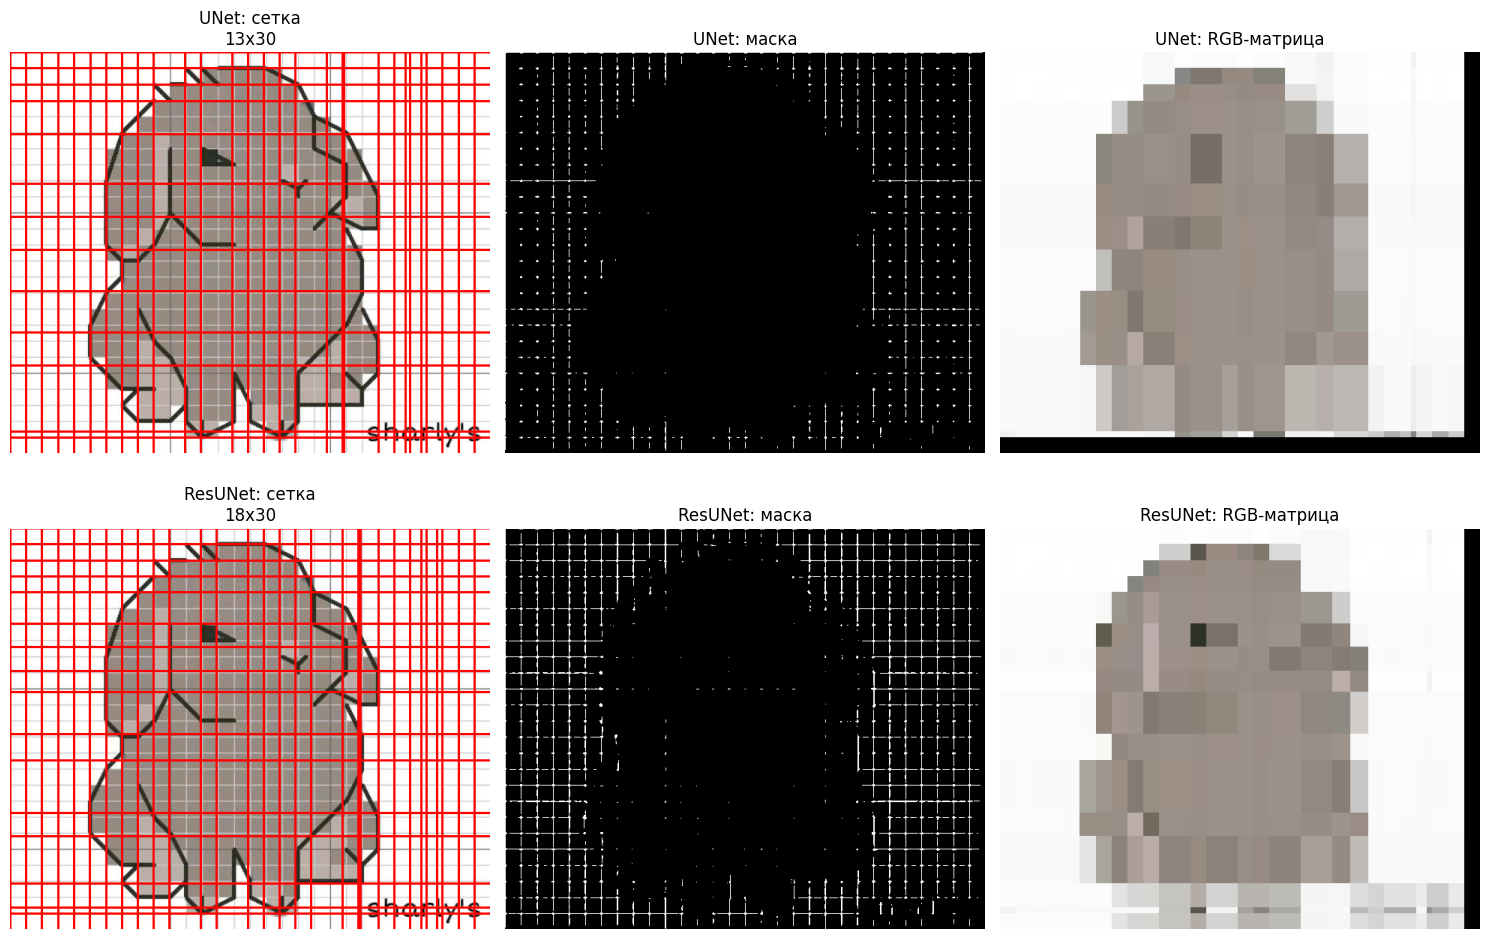

💾 Сохранено: comparison_results\comparison_i11.png

[2/3] Обработка: i57.jpg
🟢 UNet...
   ✅ Сетка: 24x23
🟢 ResUNet...
   ✅ Сетка: 24x23
   📊 UNet: IoU=0.388, Dice=0.559, Prec=0.913, Rec=0.403
   📊 ResUNet: IoU=0.459, Dice=0.630, Prec=0.893, Rec=0.486


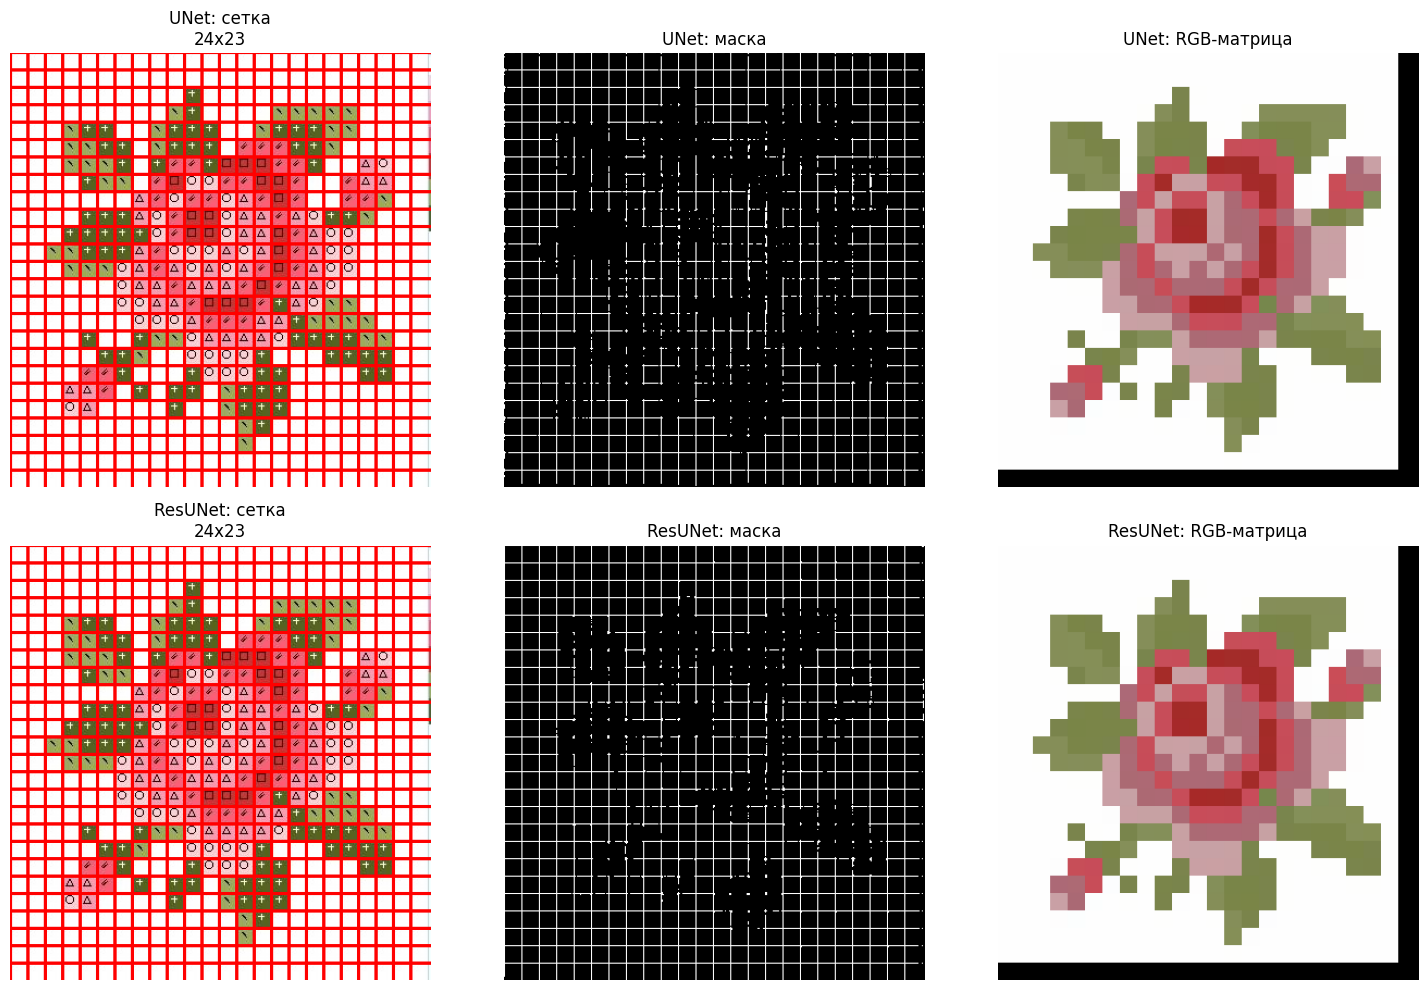

💾 Сохранено: comparison_results\comparison_i57.png

[3/3] Обработка: i9.jpg
🟢 UNet...
   ✅ Сетка: 29x31
🟢 ResUNet...
   ✅ Сетка: 38x31
   📊 UNet: IoU=0.339, Dice=0.506, Prec=0.895, Rec=0.353
   📊 ResUNet: IoU=0.482, Dice=0.650, Prec=0.893, Rec=0.511


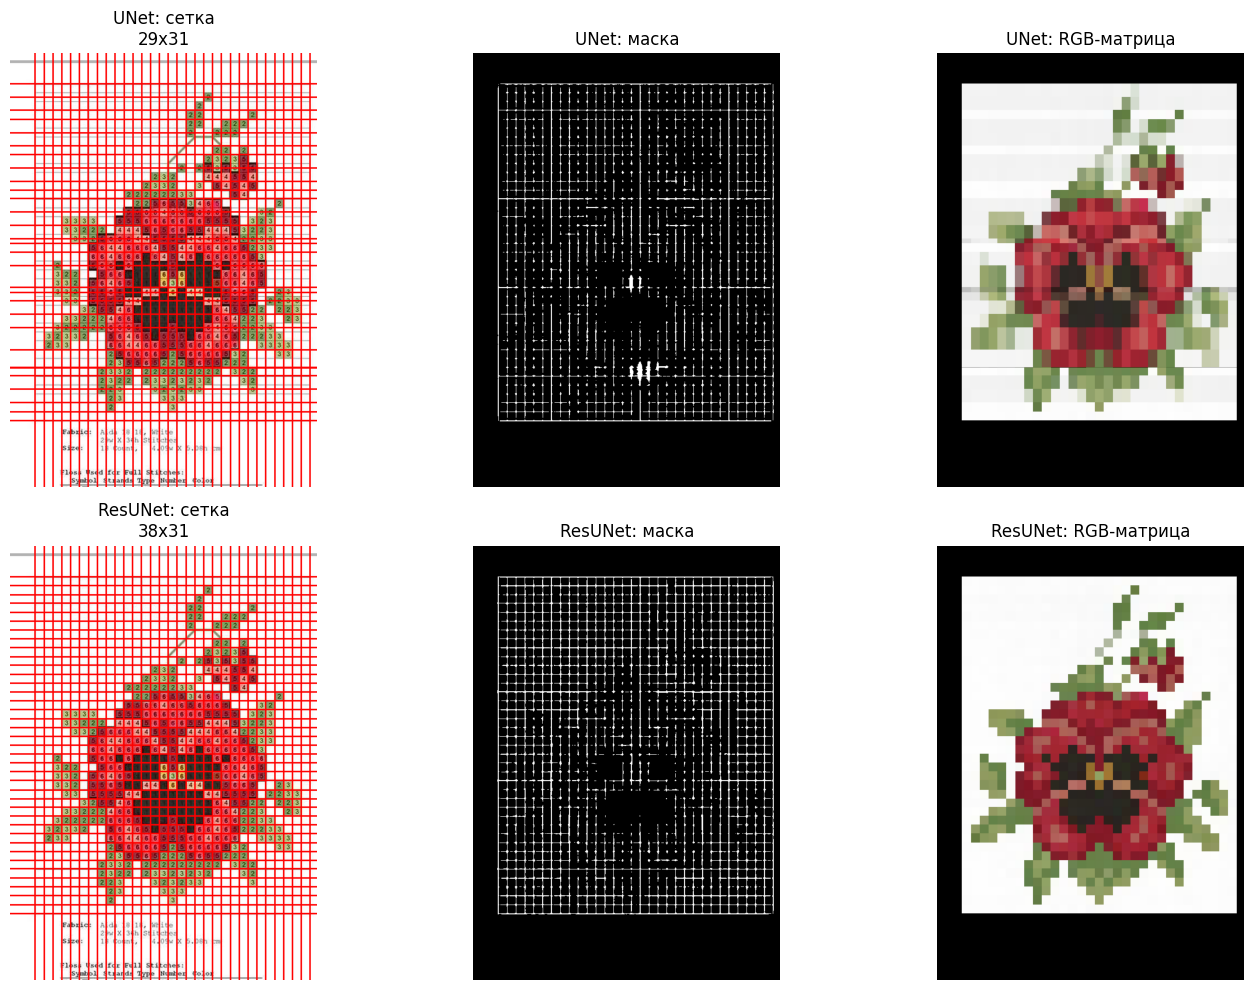

💾 Сохранено: comparison_results\comparison_i9.png

📊 СРАВНЕНИЕ МЕТРИК
Изображение                         IoU      Dice     Precision  Recall  
--------------------------------------------------------------------------------
i11.jpg                             0.099    0.180    0.915      0.100
                                    0.222    0.363    0.917      0.226  ← ResUNet
--------------------------------------------------------------------------------
i57.jpg                             0.388    0.559    0.913      0.403
                                    0.459    0.630    0.893      0.486  ← ResUNet
--------------------------------------------------------------------------------
i9.jpg                              0.339    0.506    0.895      0.353
                                    0.482    0.650    0.893      0.511  ← ResUNet
--------------------------------------------------------------------------------

📈 СРЕДНИЕ ЗНАЧЕНИЯ:
   U-Net:    IoU=0.2751, Dice=0.4149
   ResUNet:  Io

In [37]:
UNET_WEIGHTS = 'best_unet.pth'
RESUNET_WEIGHTS = 'best_resunet.pth'
TEST_IMAGES_DIR = 'test_images'

results = compare_models(
    unet_weights_path=UNET_WEIGHTS,
    resunet_weights_path=RESUNET_WEIGHTS,
    test_images_dir=TEST_IMAGES_DIR,
    output_dir='comparison_results',
    device='cuda'
)